# Classical machine learning: unrestricted 72 h versus manual 42 h

This notebook performs the paper's classical-model ablation on the Fuseki data. It forecasts the **complete next four hours** (16 values at 15-minute spacing), rather than scoring only a single convenient timestamp.

The comparison is deliberately matched:

- **Unrestricted 72 h:** the previous 288 samples of all five conductivity sensors (1,440 inputs). The model is free to infer travel times.
- **Manual 42 h:** the paper's four hand-designed scalar inputs: current target value, its one-hour change, its two-hour change, and Terneuzen shifted by exactly 42 hours.
- **Training:** January--July 2025, sampled hourly to reduce overlap.
- **Validation:** August 2025, used for conservative forecast calibration only.
- **Test:** September 2025, never used for fitting or selection.

Every model predicts a residual relative to the latest target observation. Persistence is therefore the zero-residual forecast and is reported for every horizon and for the largest 10% of changes.

In [1]:
from pathlib import Path
import os, sys, time, warnings

ROOT = Path.cwd().resolve()
if not (ROOT / "lag_analytics_workspace").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

from time_series_analysis.paper_experiment_utils import (
    build_classical_datasets,
    evaluation_rows,
    load_prepared_observations,
    split_shape_table,
    validation_calibration,
)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 20)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## 1. Load and validate the observations

The repository's Fuseki client collapses legacy duplicate measurements and normalizes conductivity to mS/cm. Preparation uses a causal trailing two-hour mean and only interpolates short internal gaps (at most one hour). No centered smoothing or future fill is used.

In [2]:
data, coverage, unit_report = load_prepared_observations()
print(f"Prepared grid: {data.shape[0]:,} rows from {data.index.min()} to {data.index.max()}")
display(coverage)
if not unit_report.empty:
    display(unit_report[[c for c in ["sensor_name", "normalization", "observations"] if c in unit_report]])

Prepared grid: 26,815 rows from 2025-01-01 00:00:00+00:00 to 2025-10-07 07:30:00+00:00


,first observation,last observation,missing after preparation,minimum mS/cm,maximum mS/cm
sensor,,,,,
Terneuzen,2025-01-01 00:00:00+00:00,2026-03-23 15:45:00+00:00,372,0.108207,2.339817
Westdorpe,2025-01-01 00:00:00+00:00,2025-10-07 07:30:00+00:00,257,0.107912,3.997718
Gent - far,2025-01-01 00:00:00+00:00,2026-03-23 12:00:00+00:00,254,0.055390,1.882214
Gent - near,2025-01-01 00:00:00+00:00,2025-12-18 23:00:00+00:00,253,0.068467,1.792810
Indusii,2025-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,962,0.000018,1.945475


,sensor_name
0,Terneuzen
1,Gent - far
2,Indusii
3,Gent - near
4,Westdorpe


In [3]:
datasets = build_classical_datasets(data)
display(split_shape_table(datasets))

,Representation,Split,X shape,y shape,First forecast,Last forecast
0,unrestricted_72h,train,"(4062, 1440)","(4062, 16)",2025-01-04 05:45:00+00:00,2025-07-31 23:45:00+00:00
1,unrestricted_72h,validation,"(2469, 1440)","(2469, 16)",2025-08-01 03:45:00+00:00,2025-08-31 23:45:00+00:00
2,unrestricted_72h,test,"(2865, 1440)","(2865, 16)",2025-09-01 03:45:00+00:00,2025-09-30 23:45:00+00:00
3,manual_42h,train,"(4062, 4)","(4062, 16)",2025-01-04 05:45:00+00:00,2025-07-31 23:45:00+00:00
4,manual_42h,validation,"(2469, 4)","(2469, 16)",2025-08-01 03:45:00+00:00,2025-08-31 23:45:00+00:00
5,manual_42h,test,"(2865, 4)","(2865, 16)",2025-09-01 03:45:00+00:00,2025-09-30 23:45:00+00:00


## 2. Models and improvements over the exploratory notebook

The original lag notebook trained separate one-hour examples and reused August in the training set. Here all methods share the same 16-output task and strict chronological split.

- **Ridge** is a strong regularized linear reference for highly correlated lag vectors.
- **XGBoost** follows the draft's nonlinear tree model but uses shallower trees, shrinkage, row/column subsampling, and L2 regularization to reduce overfit.
- **PCA + RBF-SVR** follows the draft, now with one train-only projection (at most 64 components), scaling, and a less aggressive `C` for stability. This regularizes the highly collinear 1,440-lag input without repeating PCA for each output.
- **Shallow MLP** preserves the draft's classical feed-forward baseline, with smaller learning rate, larger batches, and early stopping inside the training period.

Hyperparameters are fixed before the September test. A single multiplicative residual weight per lead time is estimated on August and constrained to `[0, 1]`; it can only shrink a model toward persistence, not amplify it.

In [4]:
def make_models(input_features):
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
        "XGBoost": XGBRegressor(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=4,
            min_child_weight=5,
            subsample=0.80,
            colsample_bytree=0.65,
            reg_alpha=0.05,
            reg_lambda=5.0,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=SEED,
            n_jobs=min(8, os.cpu_count() or 1),
        ),
        "PCA + RBF-SVR": make_pipeline(
            StandardScaler(),
            PCA(n_components=min(64, input_features), random_state=SEED),
            MultiOutputRegressor(
                SVR(kernel="rbf", C=10.0, epsilon=0.02),
                n_jobs=min(4, os.cpu_count() or 1),
            ),
        ),
        "Shallow MLP": make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                learning_rate_init=1e-3,
                batch_size=256,
                max_iter=160,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=12,
                random_state=SEED,
            ),
        ),
    }

In [5]:
all_rows, all_horizons = [], []
fit_rows, predictions = [], {}
fitted_models, calibration_weights = {}, {}

for representation, dataset in datasets.items():
    train = dataset.splits["train"]
    validation = dataset.splits["validation"]
    test = dataset.splits["test"]
    scale = dataset.target_scale
    for model_name, model in make_models(train.X.shape[1]).items():
        key = (model_name, representation)
        started = time.perf_counter()
        print(f"Fitting {model_name:12s} on {representation:18s} ...", flush=True)
        model.fit(train.X, train.y_delta / scale)
        elapsed = time.perf_counter() - started

        validation_raw = np.asarray(model.predict(validation.X), dtype=np.float32) * scale
        weights = validation_calibration(validation_raw, validation.y_delta)
        validation_calibrated = validation_raw * weights
        validation_persistence_rmse = float(np.sqrt(np.mean(validation.y_delta ** 2)))
        validation_rmse = float(np.sqrt(np.mean((validation_calibrated - validation.y_delta) ** 2)))

        test_raw = np.asarray(model.predict(test.X), dtype=np.float32) * scale
        test_calibrated = test_raw * weights
        rows, horizon, prediction = evaluation_rows(
            model_name, representation, test, test_calibrated
        )
        all_rows.extend(rows)
        all_horizons.append(horizon)
        predictions[key] = prediction
        fitted_models[key] = model
        calibration_weights[key] = weights
        fit_rows.append({
            "Model": model_name,
            "Representation": representation,
            "Fit seconds": elapsed,
            "Validation RMSE": validation_rmse,
            "Validation persistence RMSE": validation_persistence_rmse,
            "Validation RMSE skill": 1 - validation_rmse / validation_persistence_rmse,
            "Mean calibration weight": float(weights.mean()),
        })
        print(f"  {elapsed:.1f}s; validation skill {fit_rows[-1]['Validation RMSE skill']:.3f}")

fit_summary = pd.DataFrame(fit_rows).sort_values("Validation RMSE")
results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(fit_summary.round({
    "Fit seconds": 1, "Validation RMSE": 5,
    "Validation persistence RMSE": 5, "Validation RMSE skill": 3,
    "Mean calibration weight": 3,
}))

Fitting Ridge        on unrestricted_72h   ...


  0.2s; validation skill 0.133
Fitting XGBoost      on unrestricted_72h   ...


  121.2s; validation skill 0.123
Fitting PCA + RBF-SVR on unrestricted_72h   ...


  6.5s; validation skill 0.000
Fitting Shallow MLP  on unrestricted_72h   ...


  12.5s; validation skill 0.122
Fitting Ridge        on manual_42h         ...


  0.0s; validation skill 0.101
Fitting XGBoost      on manual_42h         ...


  0.9s; validation skill 0.111
Fitting PCA + RBF-SVR on manual_42h         ...


  3.7s; validation skill 0.009
Fitting Shallow MLP  on manual_42h         ...


  0.8s; validation skill 0.102


,Model,Representation,Fit seconds,Validation RMSE,Validation persistence RMSE,Validation RMSE skill,Mean calibration weight
0,Ridge,unrestricted_72h,0.2,0.21639,0.24963,0.133,0.688
1,XGBoost,unrestricted_72h,121.2,0.21892,0.24963,0.123,0.994
3,Shallow MLP,unrestricted_72h,12.5,0.21912,0.24963,0.122,0.850
5,XGBoost,manual_42h,0.9,0.22190,0.24963,0.111,1.000
7,Shallow MLP,manual_42h,0.8,0.22408,0.24963,0.102,0.789
4,Ridge,manual_42h,0.0,0.22440,0.24963,0.101,0.948
6,PCA + RBF-SVR,manual_42h,3.7,0.24734,0.24963,0.009,0.460
2,PCA + RBF-SVR,unrestricted_72h,6.5,0.24956,0.24963,0.000,0.124


## 3. Held-out September results

In [6]:
summary = results.pivot_table(
    index=["Model", "Representation"], columns="Scope",
    values=["RMSE", "R2", "RMSE skill"]
).sort_values(("RMSE", "all horizons"))
display(summary.round(4))

R2               \
Scope                          4-hour endpoint all horizons   
Model         Representation                                  
XGBoost       manual_42h                0.2404       0.4981   
Shallow MLP   unrestricted_72h          0.1714       0.4634   
Ridge         manual_42h                0.1381       0.4571   
XGBoost       unrestricted_72h          0.0939       0.4254   
Shallow MLP   manual_42h                0.0150       0.4123   
PCA + RBF-SVR unrestricted_72h          0.0341       0.3868   
              manual_42h                0.0114       0.3686   
Ridge         unrestricted_72h         -0.2195       0.2741   

                                                              RMSE  \
Scope                          largest 10% changes 4-hour endpoint   
Model         Representation                                         
XGBoost       manual_42h                   -0.3563          0.2500   
Shallow MLP   unrestricted_72h             -0.3041          0.2611   
Ridge         manual_42h                   -0.3912          0.2663   
XGBoost       unrestricted_72h             -0.2613          0.2730   
Shallow MLP   manual_42h                   -0.3995          0.2847   
PCA + RBF-SVR unrestricted_72h             -0.8194          0.2819   
              manual_42h                   -0.8150          0.2852   
Ridge         unrestricted_72h             -0.5032          0.3168   

                                                                 \
Scope                          all horizons largest 10% changes   
Model         Representation                                      
XGBoost       manual_42h             0.2030              0.5050   
Shallow MLP   unrestricted_72h       0.2099              0.4952   
Ridge         manual_42h             0.2111              0.5115   
XGBoost       unrestricted_72h       0.2172              0.4870   
Shallow MLP   manual_42h             0.2197              0.5130   
PCA + RBF-SVR unrestricted_72h       0.2244              0.5849   
              manual_42h             0.2277              0.5842   
Ridge         unrestricted_72h       0.2441              0.5316   

                                    RMSE skill               \
Scope                          4-hour endpoint all horizons   
Model         Representation                                  
XGBoost       manual_42h                0.1132       0.0952   
Shallow MLP   unrestricted_72h          0.0738       0.0644   
Ridge         manual_42h                0.0554       0.0589   
XGBoost       unrestricted_72h          0.0315       0.0318   
Shallow MLP   manual_42h               -0.0098       0.0209   
PCA + RBF-SVR unrestricted_72h          0.0000      -0.0001   
              manual_42h               -0.0117      -0.0149   
Ridge         unrestricted_72h         -0.1236      -0.0882   

                                                    
Scope                          largest 10% changes  
Model         Representation                        
XGBoost       manual_42h                    0.1366  
Shallow MLP   unrestricted_72h              0.1534  
Ridge         manual_42h                    0.1256  
XGBoost       unrestricted_72h              0.1674  
Shallow MLP   manual_42h                    0.1230  
PCA + RBF-SVR unrestricted_72h              0.0000  
              manual_42h                    0.0012  
Ridge         unrestricted_72h              0.0910

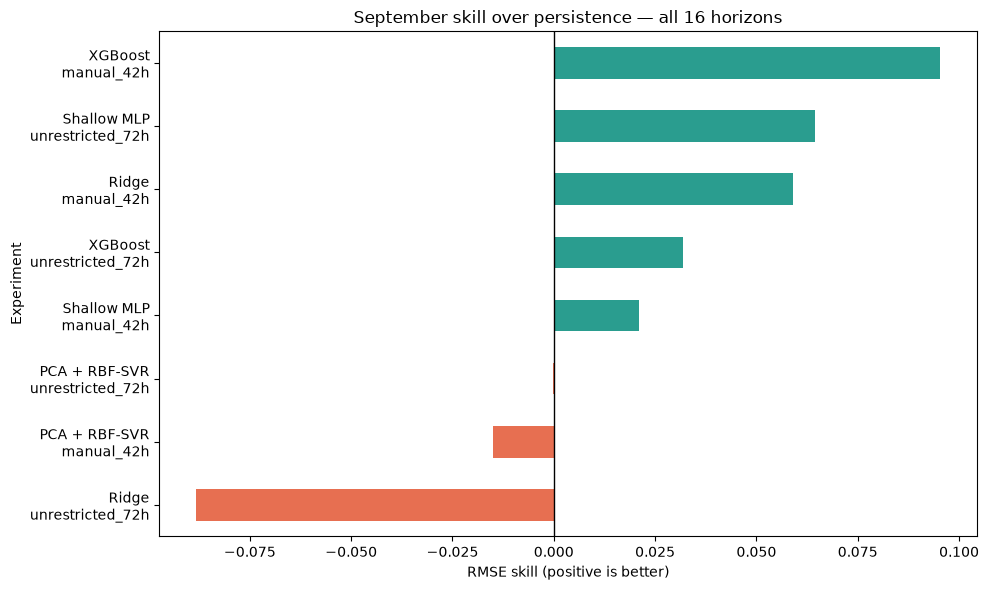

In [7]:
plot_data = results[results["Scope"] == "all horizons"].copy()
plot_data["Experiment"] = plot_data["Model"] + "\n" + plot_data["Representation"]
ax = plot_data.sort_values("RMSE skill").plot.barh(
    x="Experiment", y="RMSE skill", figsize=(10, 6), legend=False,
    color=np.where(plot_data.sort_values("RMSE skill")["RMSE skill"] >= 0, "#2a9d8f", "#e76f51")
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("September skill over persistence — all 16 horizons")
ax.set_xlabel("RMSE skill (positive is better)")
plt.tight_layout()
plt.show()

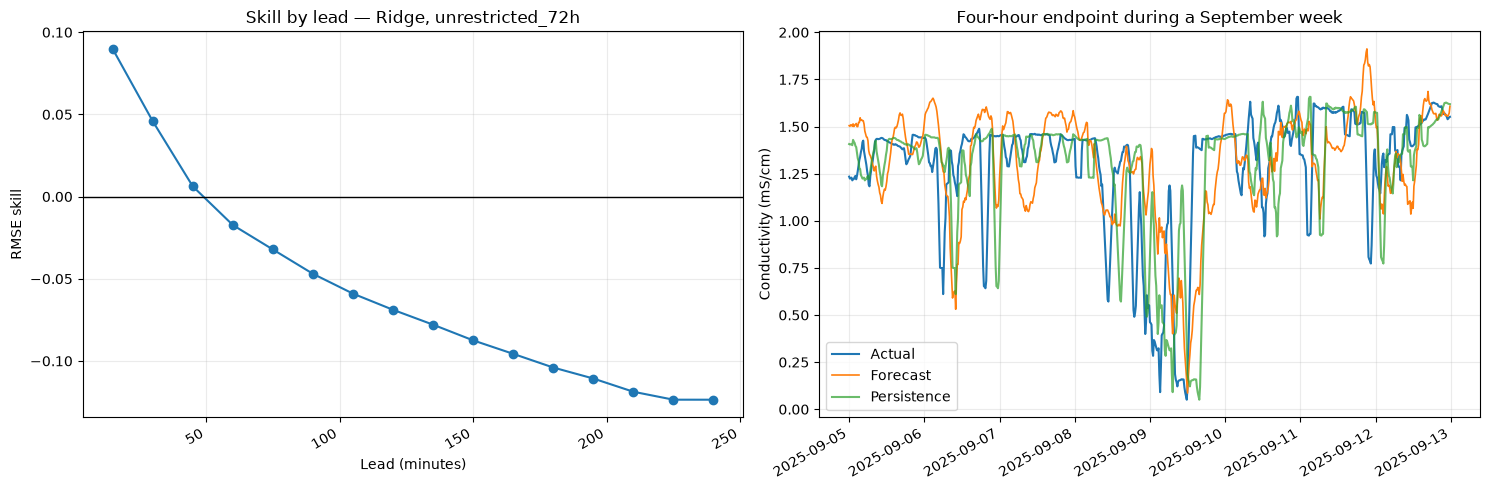

In [8]:
# Select the display model by August validation RMSE, not by September results.
best_row = fit_summary.iloc[0]
best_key = (best_row["Model"], best_row["Representation"])
best_horizon = horizon_results[
    (horizon_results["Model"] == best_key[0]) &
    (horizon_results["Representation"] == best_key[1])
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(best_horizon["Lead minutes"], best_horizon["RMSE skill"], marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title=f"Skill by lead — {best_key[0]}, {best_key[1]}", xlabel="Lead (minutes)", ylabel="RMSE skill")
axes[0].grid(alpha=.25)

week = predictions[best_key].loc["2025-09-05":"2025-09-12"]
axes[1].plot(week.index, week["Actual"], label="Actual", linewidth=1.5)
axes[1].plot(week.index, week["Prediction"], label="Forecast", linewidth=1.2)
axes[1].plot(week.index, week["Persistence"], label="Persistence", alpha=.7)
axes[1].set(title="Four-hour endpoint during a September week", ylabel="Conductivity (mS/cm)")
axes[1].legend()
axes[1].grid(alpha=.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Reproducible conclusion

In [9]:
for representation in datasets:
    chosen = fit_summary[fit_summary["Representation"] == representation].iloc[0]
    test_row = results[
        (results["Model"] == chosen["Model"]) &
        (results["Representation"] == representation) &
        (results["Scope"] == "all horizons")
    ].iloc[0]
    print(
        f"{representation}: August selected {chosen['Model']}; "
        f"September RMSE={test_row['RMSE']:.5f}, "
        f"skill vs persistence={test_row['RMSE skill']:.3f}."
    )

best_test = results[results["Scope"] == "all horizons"].sort_values("RMSE").iloc[0]
print(
    f"\nLowest September RMSE among the pre-specified experiments: {best_test['Model']} "
    f"with {best_test['Representation']} ({best_test['RMSE']:.5f}; "
    f"skill {best_test['RMSE skill']:.3f})."
)

unrestricted_72h: August selected Ridge; September RMSE=0.24415, skill vs persistence=-0.088.
manual_42h: August selected XGBoost; September RMSE=0.20300, skill vs persistence=0.095.

Lowest September RMSE among the pre-specified experiments: XGBoost with manual_42h (0.20300; skill 0.095).
